# Ablation: Token Accuracy & Exact Match vs. Rollout Steps

This notebook plots results from the three sudoku-extreme ablation eval runs
(MLM uniform, Loopholing no-BPTT, Loopholing BPTT).

**Backends supported** (set `BACKEND` below):
- `"auto"` — tries W&B first; if no runs found, falls back to TensorBoard
- `"wandb"` — reads from W&B API
- `"tensorboard"` — reads from local TensorBoard event files

**Prerequisites:**
```
pip install -r plotting_scripts/requirements-plot.txt
```

In [12]:
print("Hello world!")

Hello world!


In [13]:
# ── Configuration ─────────────────────────────────────────────────────────────

BACKEND = "auto"   # "auto" | "wandb" | "tensorboard"

# W&B settings (used when BACKEND is "auto" or "wandb")
WANDB_ENTITY  = "ilm-extensions"
WANDB_PROJECT = "BPTT-puzzles"
WANDB_GROUP   = "ablation_threshold_sweep_300k"

# Checkpoint step label — used in job names, run names, and figure titles
STEPS_TAG = "300k"

# TensorBoard log roots (used when BACKEND is "auto" or "tensorboard")
# Pattern: logs/ablation_eval_{model}_{STEPS_TAG}/tensorboard/version_0/
import os
PROJECT_ROOT = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..")
TB_LOG_ROOTS = {
    "ablation_eval_mlm_300k":    os.path.join(PROJECT_ROOT, "logs", f"ablation_eval_mlm_{STEPS_TAG}",    "tensorboard", "version_0"),
    "ablation_eval_no_bptt_300k": os.path.join(PROJECT_ROOT, "logs", f"ablation_eval_no_bptt_{STEPS_TAG}", "tensorboard", "version_0"),
    "ablation_eval_bptt_300k":   os.path.join(PROJECT_ROOT, "logs", f"ablation_eval_bptt_{STEPS_TAG}",   "tensorboard", "version_0"),
}

# Human-readable labels and plot styles for each run key
MODEL_CONFIGS = {
    f"ablation_eval_mlm_{STEPS_TAG}":          {"label": "MLM uniform",                  "color": "C2", "marker": "D"},
    f"ablation_eval_no_bptt_{STEPS_TAG}":       {"label": "Loopholing (no BPTT)",         "color": "C1", "marker": "s"},
    f"ablation_eval_bptt_{STEPS_TAG}":          {"label": "Loopholing (BPTT)",            "color": "C0", "marker": "o"},
    f"ablation_eval_bptt_tied_emb_{STEPS_TAG}": {"label": "Loopholing (BPTT, tied emb)", "color": "C3", "marker": "^"},
}

# W&B run IDs for runs whose key does not match their W&B run id.
# Maps model config key → W&B run id.
WANDB_RUN_ID_MAP = {
    f"ablation_eval_bptt_tied_emb_{STEPS_TAG}": "pucld8o9",
}

# Thresholds swept by ValidationThresholdSweepCallback
THRESHOLDS = [0.05, 0.10, 0.15, 0.20, 0.25]

# Output directory for saved figures
OUTPUT_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "ablation_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [14]:
import glob
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [15]:
# ── Threshold tag helpers ──────────────────────────────────────────────────────
# ValidationThresholdSweepCallback._to_tag: 0.05 → "0p05", 0.10 → "0p10", etc.

def threshold_tag(t: float) -> str:
    return f"{t:.2f}".replace(".", "p")

METRIC_TAGS = {
    t: {
        "rollout_steps":  f"val_sweep/t_{threshold_tag(t)}/rollout_steps",
        "exact_match":    f"val_sweep/t_{threshold_tag(t)}/exact_match",
        "token_accuracy": f"val_sweep/t_{threshold_tag(t)}/token_accuracy",
    }
    for t in THRESHOLDS
}

## Backend: W&B

In [16]:
def fetch_from_wandb(entity, project, group, steps_tag):
    """
    Returns {run_key: {threshold: {metric: value}}} pulled from W&B.
    Tries group filter first; falls back to run-id lookup.
    Returns None if wandb is unavailable or no runs found.
    """
    try:
        import wandb
        api = wandb.Api()
    except Exception as e:
        print(f"W&B unavailable: {e}")
        return None

    # Try group filter first
    try:
        runs = list(api.runs(f"{entity}/{project}", filters={"group": group}))
        print(f"W&B: found {len(runs)} run(s) in group '{group}'")
    except Exception as e:
        print(f"W&B group query failed: {e}")
        runs = []

    # Fall back to run-id lookup
    if not runs:
        print("W&B: no runs via group – trying lookup by run id (job_name)")
        for key in MODEL_CONFIGS:
            # Use explicit W&B run id from WANDB_RUN_ID_MAP when available,
            # otherwise assume the config key is the run id.
            wandb_id = WANDB_RUN_ID_MAP.get(key, key)
            try:
                run = api.run(f"{entity}/{project}/{wandb_id}")
                runs.append(run)
            except Exception:
                pass
        print(f"W&B: found {len(runs)} run(s) by id")

    if not runs:
        return None

    result = {}
    # Build a reverse map: W&B run id → config key (for WANDB_RUN_ID_MAP entries)
    wandb_id_to_key = {v: k for k, v in WANDB_RUN_ID_MAP.items()}
    for run in runs:
        # Match run to a model config by id, name, or WANDB_RUN_ID_MAP
        run_key = wandb_id_to_key.get(run.id) or wandb_id_to_key.get(run.name)
        if run_key is None:
            for key in MODEL_CONFIGS:
                if run.id == key or run.name == key:
                    run_key = key
                    break
        if run_key is None:
            print(f"  Skipping unrecognised W&B run: id={run.id} name={run.name}")
            continue

        per_threshold = {}
        for t in THRESHOLDS:
            tags = METRIC_TAGS[t]
            rs = run.summary.get(tags["rollout_steps"])
            em = run.summary.get(tags["exact_match"])
            ta = run.summary.get(tags["token_accuracy"])
            if None in (rs, em, ta):
                print(f"  WARNING [{run_key}] t={t}: missing metric(s)")
                continue
            per_threshold[t] = {
                "rollout_steps":  float(rs),
                "exact_match":    float(em),
                "token_accuracy": float(ta),
            }
        if per_threshold:
            result[run_key] = per_threshold
            print(f"  {run_key}: {len(per_threshold)} thresholds")

    return result if result else None

## Backend: TensorBoard

In [17]:
def fetch_from_tensorboard(tb_log_roots):
    """
    Returns {run_key: {threshold: {metric: value}}} read from local TB event files.
    Each run_key maps to a TensorBoard log directory.
    Returns None if tensorboard is unavailable or no event files are found.
    """
    try:
        from tensorboard.backend.event_processing.event_accumulator import (
            EventAccumulator,
        )
    except ImportError:
        print("tensorboard package not installed. Run: pip install tensorboard")
        return None

    result = {}
    for run_key, logdir in tb_log_roots.items():
        # Find the most recent event file (handle multiple restarts)
        event_files = sorted(glob.glob(os.path.join(logdir, "events.out.tfevents*")))
        if not event_files:
            print(f"  No TensorBoard event files found in: {logdir}")
            continue

        print(f"  Loading TensorBoard: {run_key}  ({len(event_files)} event file(s))")
        ea = EventAccumulator(logdir, size_guidance={"scalars": 0})
        ea.Reload()

        available_tags = set(ea.Tags().get("scalars", []))

        per_threshold = {}
        for t in THRESHOLDS:
            tags = METRIC_TAGS[t]
            missing = [k for k, v in tags.items() if v not in available_tags]
            if missing:
                print(f"    WARNING t={t}: missing {missing} (available: {sorted(available_tags)[:8]}...)")
                continue

            # Take the last logged value for each scalar
            def last_value(tag):
                events = ea.Scalars(tag)
                return events[-1].value if events else None

            rs = last_value(tags["rollout_steps"])
            em = last_value(tags["exact_match"])
            ta = last_value(tags["token_accuracy"])
            if None in (rs, em, ta):
                continue
            per_threshold[t] = {
                "rollout_steps":  rs,
                "exact_match":    em,
                "token_accuracy": ta,
            }

        if per_threshold:
            result[run_key] = per_threshold
            print(f"    → {len(per_threshold)} thresholds loaded")
        else:
            print(f"    → no threshold data yet (job still running?)")

    return result if result else None

## Load data

In [18]:
parsed = {}
backends_used = []

if BACKEND in ("auto", "wandb"):
    print("=== Trying W&B ===")
    wb_data = fetch_from_wandb(WANDB_ENTITY, WANDB_PROJECT, WANDB_GROUP, STEPS_TAG)
    if wb_data:
        parsed.update(wb_data)
        backends_used.append("wandb")
        print(f"\nW&B data: {len(wb_data)} model(s)")
    elif BACKEND == "wandb":
        raise RuntimeError("No W&B data found and BACKEND='wandb'. Check entity/project/group.")

# Always try TensorBoard for any model keys still missing from parsed
missing_keys = [k for k in MODEL_CONFIGS if k not in parsed]
if missing_keys and BACKEND in ("auto", "tensorboard"):
    missing_tb_roots = {k: v for k, v in TB_LOG_ROOTS.items() if k in missing_keys}
    if missing_tb_roots:
        print("\n=== Trying TensorBoard ===")
        tb_data = fetch_from_tensorboard(missing_tb_roots)
        if tb_data:
            parsed.update(tb_data)
            backends_used.append("tensorboard")
            print(f"\nTensorBoard data: {len(tb_data)} model(s)")
        elif BACKEND == "tensorboard":
            raise RuntimeError("No TensorBoard data found and BACKEND='tensorboard'. Check TB_LOG_ROOTS.")

if not parsed:
    raise RuntimeError(
        "No data found from either backend. "
        "Are the eval jobs still running? "
        "Check TB_LOG_ROOTS paths and W&B credentials."
    )

print(f"\nBackends used : {', '.join(backends_used) if backends_used else 'none'}")
print(f"Models loaded : {list(parsed.keys())}")

=== Trying W&B ===
W&B: found 0 run(s) in group 'ablation_threshold_sweep_300k'
W&B: no runs via group – trying lookup by run id (job_name)
W&B: found 1 run(s) by id
  ablation_eval_bptt_tied_emb_300k: 5 thresholds

W&B data: 1 model(s)

=== Trying TensorBoard ===
  Loading TensorBoard: ablation_eval_mlm_300k  (1 event file(s))
    → 5 thresholds loaded
  Loading TensorBoard: ablation_eval_no_bptt_300k  (1 event file(s))
    → 5 thresholds loaded
  Loading TensorBoard: ablation_eval_bptt_300k  (1 event file(s))
    → 5 thresholds loaded

TensorBoard data: 3 model(s)

Backends used : wandb, tensorboard
Models loaded : ['ablation_eval_bptt_tied_emb_300k', 'ablation_eval_mlm_300k', 'ablation_eval_no_bptt_300k', 'ablation_eval_bptt_300k']


In [19]:
# ── Print raw numbers ──────────────────────────────────────────────────────────

rows = []
for run_key, data in parsed.items():
    label = MODEL_CONFIGS[run_key]["label"]
    for t, metrics in sorted(data.items()):
        rows.append({
            "model":          label,
            "threshold":      t,
            "rollout_steps":  round(metrics["rollout_steps"],  3),
            "token_accuracy": round(metrics["token_accuracy"], 4),
            "exact_match":    round(metrics["exact_match"],    4),
        })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

csv_path = os.path.join(OUTPUT_DIR, f"ablation_metrics_{STEPS_TAG}.csv")
df.to_csv(csv_path, index=False)
print(f"\nSaved CSV: {csv_path}")

                      model  threshold  rollout_steps  token_accuracy  exact_match
Loopholing (BPTT, tied emb)       0.05         26.700          0.8528       0.7445
Loopholing (BPTT, tied emb)       0.10         23.230          0.8375       0.7007
Loopholing (BPTT, tied emb)       0.15         21.010          0.8226       0.6580
Loopholing (BPTT, tied emb)       0.20         19.050          0.8070       0.6152
Loopholing (BPTT, tied emb)       0.25         17.720          0.7925       0.5740
                MLM uniform       0.05         37.428          0.6327       0.3257
                MLM uniform       0.10         35.580          0.6315       0.3112
                MLM uniform       0.15         33.316          0.6264       0.2847
                MLM uniform       0.20         30.432          0.6196       0.2565
                MLM uniform       0.25         27.638          0.6137       0.2313
       Loopholing (no BPTT)       0.05         29.236          0.8358       0.7035
    

## Plots

In [20]:
def plot_metric_vs_rollout(
    parsed_data,
    metric,
    y_label,
    title,
    out_path=None,
    figsize=(7, 5),
):
    """
    Plot <metric> vs rollout_steps for each model type.
    Each curve = one model; each point = one confidence threshold (annotated).
    Points are connected in order of increasing threshold.
    """
    fig, ax = plt.subplots(figsize=figsize)

    for run_key, cfg in MODEL_CONFIGS.items():
        if run_key not in parsed_data:
            print(f"  No data for {run_key} – skipping.")
            continue

        points = parsed_data[run_key]
        sorted_thresholds = sorted(points.keys())
        xs = [points[t]["rollout_steps"] for t in sorted_thresholds]
        ys = [points[t][metric]           for t in sorted_thresholds]

        ax.plot(
            xs, ys,
            marker=cfg["marker"],
            color=cfg["color"],
            label=cfg["label"],
            linewidth=2,
            markersize=8,
            zorder=3,
        )
        for t, x, y in zip(sorted_thresholds, xs, ys):
            ax.annotate(
                f"{t:.2f}",
                xy=(x, y),
                xytext=(5, 6),
                textcoords="offset points",
                fontsize=8,
                color=cfg["color"],
            )

    ax.set_xlabel("Rollout Steps (avg per example)", fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    if out_path:
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {out_path}")

    plt.show()
    return fig, ax

Saved: /work/pi_mccallum_umass_edu/brozonoyer_umass_edu/double-backprop/plotting_scripts/ablation_plots/token_accuracy_vs_rollout_300k.png


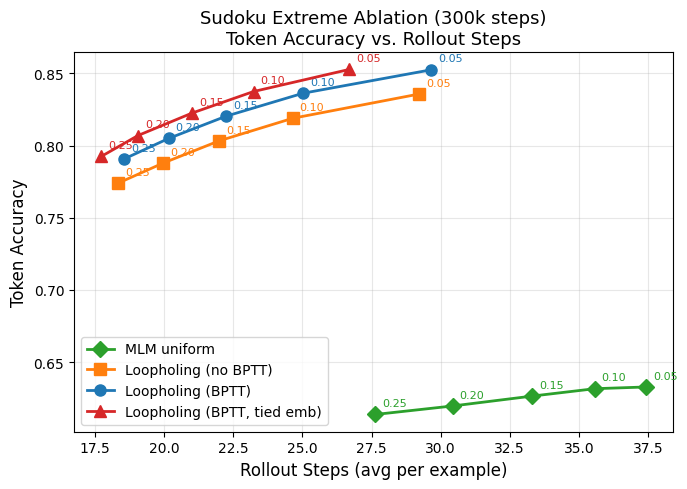

(<Figure size 700x500 with 1 Axes>,
 <Axes: title={'center': 'Sudoku Extreme Ablation (300k steps)\nToken Accuracy vs. Rollout Steps'}, xlabel='Rollout Steps (avg per example)', ylabel='Token Accuracy'>)

In [21]:
# ── Figure 1: Token Accuracy vs. Rollout Steps ────────────────────────────────

plot_metric_vs_rollout(
    parsed,
    metric="token_accuracy",
    y_label="Token Accuracy",
    title=f"Sudoku Extreme Ablation ({STEPS_TAG} steps)\nToken Accuracy vs. Rollout Steps",
    out_path=os.path.join(OUTPUT_DIR, f"token_accuracy_vs_rollout_{STEPS_TAG}.png"),
)

Saved: /work/pi_mccallum_umass_edu/brozonoyer_umass_edu/double-backprop/plotting_scripts/ablation_plots/exact_match_vs_rollout_300k.png


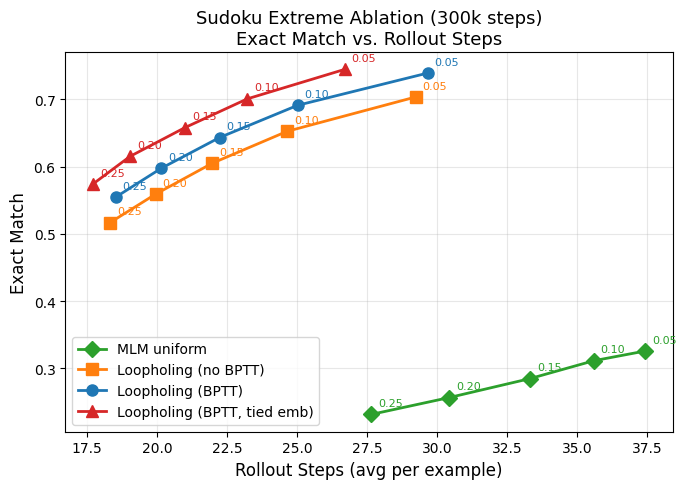

(<Figure size 700x500 with 1 Axes>,
 <Axes: title={'center': 'Sudoku Extreme Ablation (300k steps)\nExact Match vs. Rollout Steps'}, xlabel='Rollout Steps (avg per example)', ylabel='Exact Match'>)

In [22]:
# ── Figure 2: Exact Match vs. Rollout Steps ───────────────────────────────────

plot_metric_vs_rollout(
    parsed,
    metric="exact_match",
    y_label="Exact Match",
    title=f"Sudoku Extreme Ablation ({STEPS_TAG} steps)\nExact Match vs. Rollout Steps",
    out_path=os.path.join(OUTPUT_DIR, f"exact_match_vs_rollout_{STEPS_TAG}.png"),
)